In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
hbar = 6.58e-16   # Planck's constant in eV*s
v_fermi = 1e6  # Fermi velocity in m
gamma_1 = 0.39 # eV, interlayer coupling energy

def e1(q):
    return -gamma_1 - (hbar * v_fermi * q)**2
def e2(q):
    return - (hbar * v_fermi * q)**2

def e3(q):
    return (hbar * v_fermi * q)**2
def e4(q):
    return gamma_1 + (hbar * v_fermi * q)**2



In [4]:
q_max = 0.05e10  # Maximum q value in 1/m

q_values = np.linspace(-q_max, q_max, 100)

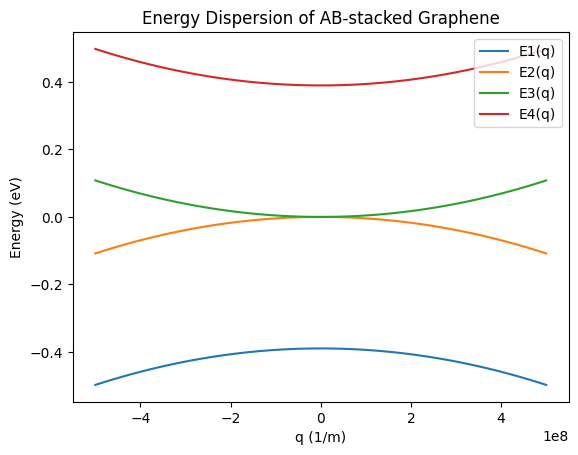

In [11]:
plt.plot(q_values, e1(q_values), label='E1(q)')
plt.plot(q_values, e2(q_values), label='E2(q)')
plt.plot(q_values, e3(q_values), label='E3(q)')
plt.plot(q_values, e4(q_values), label='E4(q)')
plt.xlabel('q (1/m)')
plt.ylabel('Energy (eV)')
plt.title('Energy Dispersion of AB-stacked Graphene')
plt.legend()


Applying voltage:

In [12]:
V = 0.1 # Voltage in volts
def Hamilt(q):
    f = hbar * v_fermi * q
    H = np.array(
        [[-V/2, f-V/2, 0, 0],
         [f-V/2, -V/2, gamma_1, 0],
         [0, gamma_1, V/2, f+V/2],
         [0, 0, f+V/2, V/2]
        ]
    )
    return H


In [13]:
q = 0 
eigenvalues = np.linalg.eigvals(Hamilt(q))
eigenvalues

array([-0.39964892,  0.39964892, -0.04879283,  0.04879283])

In [14]:
e_volt = [[] for _ in range(4)]

for q in q_values:
    eigvals = np.linalg.eigvals(Hamilt(q))
    eigvals = np.sort_complex(eigvals)
    for i, val in enumerate(eigvals):
        e_volt[i].append(val)

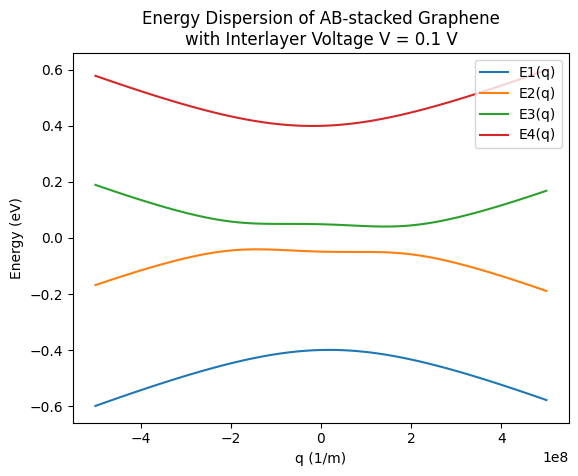

In [15]:
plt.plot(q_values, e_volt[0], label='E1(q)')
plt.plot(q_values, e_volt[1], label='E2(q)')
plt.plot(q_values, e_volt[2], label='E3(q)')
plt.plot(q_values, e_volt[3], label='E4(q)')
plt.xlabel('q (1/m)')
plt.ylabel('Energy (eV)')
plt.title('Energy Dispersion of AB-stacked Graphene\nwith Interlayer Voltage V = {V} V'.format(V=V))
plt.legend()
